# 07 · Mengatasi Heterogenitas: FedProx & Clustered FL

Notebook 05 menunjukkan bahwa saat pola antar bank berbeda (non-IID), satu model global (FedAvg) memburuk.
Tiga strategi yang dibandingkan di sini, semuanya **tanpa berbagi data**:

1. **FedProx**: penalti $\frac{\mu}{2}\lVert w - w_{global}\rVert^2$ agar model lokal tidak menjauh dari model global.
2. **Personalisasi (fine-tune)**: model global disesuaikan sedikit ke tiap bank.
3. **Clustered FL** (Sattler dkk., 2020): server mengelompokkan bank berdasarkan **kemiripan arah update bobot**,
   lalu melatih satu model per kelompok.

Skenario baru **`klaster`** berisi dua kelompok bank (misalnya ritel vs korporat). Kelompok 0 punya efek
gajian kuat, sedangkan kelompok 1 tidak punya efek gajian tetapi efek Lebarannya dua kali lebih kuat.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.data import get_scenario, simulate
from fedprob.experiment import run_experiment_cached, method_label
from fedprob.plots import plot_series

sim = simulate(get_scenario("klaster"))
pd.DataFrame([{ "bank": b.name, "kelompok": b.group, "gajian": b.payday_amp, "lebaran": b.lebaran_amp,
                "pola mingguan": np.round(b.weekly, 1)} for b in sim.banks])

,bank,kelompok,gajian,lebaran,pola mingguan
0,Bank A,0,2.774,5.430,"[5.1, -6.7, -3.0, 3.2, -1.8, 1.5, 1.8]"
1,Bank B,1,0.000,12.953,"[0.2, -0.4, -2.0, 1.4, 2.6, -1.8, 0.1]"
2,Bank C,0,2.864,4.013,"[5.2, -6.8, -2.7, 2.8, -1.8, 2.2, 1.1]"
3,Bank D,1,0.000,12.871,"[0.4, -0.1, -3.0, 1.5, 3.3, -1.4, -0.7]"
4,Bank E,0,3.466,4.883,"[4.8, -6.9, -3.3, 3.2, -1.9, 2.1, 2.1]"
5,Bank F,1,0.000,12.738,"[0.0, 0.2, -2.9, 2.0, 2.6, -1.4, -0.5]"
6,Bank G,0,2.465,5.146,"[5.4, -7.1, -3.5, 2.7, -1.9, 2.4, 2.0]"
7,Bank H,1,0.000,12.543,"[0.1, -0.3, -2.1, 2.8, 2.9, -2.0, -1.3]"


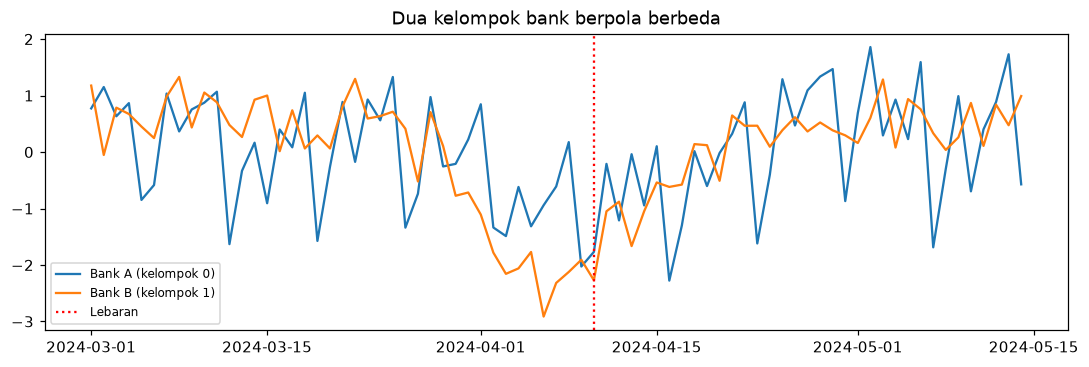

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.5))
s = slice(sim.dates.get_loc("2024-03-01"), sim.dates.get_loc("2024-05-15"))
for k in [0, 1]:
    y = sim.y[:, k]; ax.plot(sim.dates[s], (y[s] - y[s].mean()) / y[s].std(), label=f"{sim.banks[k].name} (kelompok {sim.banks[k].group})")
ax.axvline(pd.Timestamp("2024-04-10"), color="red", ls=":", label="Lebaran")
ax.set_title("Dua kelompok bank berpola berbeda"); ax.legend(fontsize=8)

## Apakah server bisa menemukan kelompok tanpa melihat data?

In [4]:
res = {s: run_experiment_cached(s, cache_dir="../results", verbose=False) for s in ["normal", "heterogen", "klaster"]}
for s, r in res.items():
    print(f"{s:10s} klaster ditemukan: {r.extras['cluster_labels']}   kelompok sebenarnya: {[b.group for b in r.sim.banks]}")

normal     klaster ditemukan: [0 0 0 0 0 0 0 0]   kelompok sebenarnya: [0, 0, 0, 0, 0, 0, 0, 0]
heterogen  klaster ditemukan: [0 0 0 0 0 0 0 0]   kelompok sebenarnya: [0, 0, 0, 0, 0, 0, 0, 0]
klaster    klaster ditemukan: [1 0 1 0 1 0 1 0]   kelompok sebenarnya: [0, 1, 0, 1, 0, 1, 0, 1]


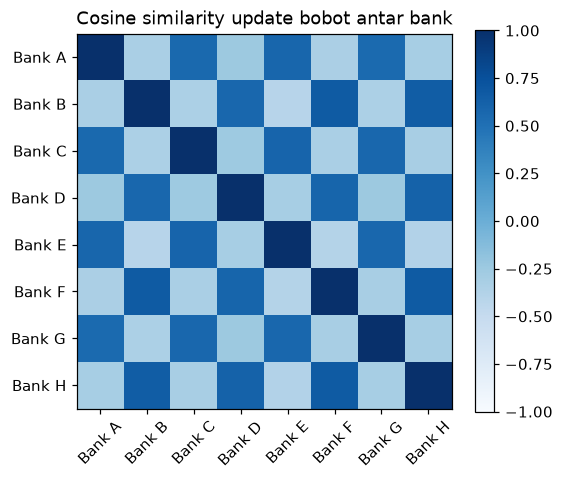

In [5]:
r = res["klaster"]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(r.extras["cluster_similarity"], cmap="Blues", vmin=-1, vmax=1)
names = [b.name for b in r.sim.banks]
ax.set_xticks(range(8), names, rotation=45); ax.set_yticks(range(8), names)
ax.set_title("Cosine similarity update bobot antar bank"); plt.colorbar(im)

Pada `klaster`, bank genap (A, C, E, G) dan ganjil (B, D, F, H) jelas membentuk dua blok. Server menemukan
kelompok yang **tepat** hanya dari update bobot. Pada `normal` dan `heterogen` tidak ada struktur kelompok
(silhouette < 0.3), sehingga Clustered FL dengan benar kembali menjadi FedAvg biasa.

## Perbandingan CRPS

In [6]:
M = ["local", "fedavg", "fedprox", "fedavg_ft", "clustered", "central", "oracle"]
pd.DataFrame({s: r.summary().loc[M, "CRPS"] for s, r in res.items()}).rename(index=method_label).style.format("{:.3f}").highlight_min(axis=0, subset=pd.IndexSlice[[method_label(m) for m in M[:-2]], :], color="#cde7cd")

,normal,heterogen,klaster
method,,,
Local-only (tiap bank sendiri),0.195,0.201,0.261
Federated (FedAvg),0.203,0.223,0.277
Federated (FedProx),0.193,0.213,0.275
FedAvg + fine-tune lokal,0.201,0.205,0.254
Clustered FL,0.205,0.224,0.252
Centralized (data digabung),0.199,0.212,0.274
Oracle (distribusi sebenarnya),0.162,0.173,0.224


## Sensitivitas FedProx terhadap mu

In [7]:
rows = []
for s in ["normal", "heterogen", "klaster"]:
    for mu in [0.01, 0.1, 1.0]:
        r = run_experiment_cached(s, methods=("fedprox",), fedprox_mu=mu, cache_dir="../results", verbose=False)
        rows.append({"skenario": s, "mu": mu, **r.summary().loc["fedprox", ["CRPS", "Coverage80", "Lebar80"]]})
pd.DataFrame(rows).pivot_table(index="mu", columns="skenario", values=["CRPS", "Coverage80"])

CRPS                Coverage80               
skenario heterogen klaster normal  heterogen klaster normal
mu                                                         
0.01         0.223   0.276  0.198      0.691   0.696  0.664
0.10         0.213   0.275  0.193      0.793   0.745  0.798
1.00         0.345   0.387  0.309      0.950   0.907  0.986

## Kesimpulan
- **Clustered FL** menemukan struktur kelompok yang sebenarnya hanya dari update bobot, dan pada `klaster`
  mengalahkan FedAvg maupun Local. Bila tidak ada struktur, ia otomatis kembali menjadi FedAvg.
- **Fine-tune lokal** adalah cara paling sederhana dan konsisten untuk menangani heterogenitas acak (`heterogen`).
- **FedProx** sensitif terhadap mu: mu=0.1 sedikit membantu, sedangkan mu=1.0 terlalu mengekang (CRPS buruk,
  interval terlalu lebar).